In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import datasets

In [3]:
# data = {
#     'Age': [22, 25, 47, 52, 46, 56, 23, 39, 45, 35],
#     'Fare': [7.25, 71.83, 7.92, 8.05, 26.0, 83.16, 8.05, 31.28, 35.5, 8.05],
#     'Survived': [0, 1, 0, 0, 1, 1, 0, 1, 0, 0]  # Target variable (0 = No, 1 = Yes)
# }

In [4]:
!pip install datasets

In [5]:
from datasets import load_dataset
dataset = load_dataset('victor/titanic')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

train_and_test2.csv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/1309 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1309 [00:00<?, ? examples/s]

In [7]:
dataset

DatasetDict({
    train: Dataset({
        features: ['Passengerid', 'Age', 'Fare', 'Sex', 'sibsp', 'zero', 'zero.1', 'zero.2', 'zero.3', 'zero.4', 'zero.5', 'zero.6', 'Parch', 'zero.7', 'zero.8', 'zero.9', 'zero.10', 'zero.11', 'zero.12', 'zero.13', 'zero.14', 'Pclass', 'zero.15', 'zero.16', 'Embarked', 'zero.17', 'zero.18', '2urvived'],
        num_rows: 1309
    })
    test: Dataset({
        features: ['Passengerid', 'Age', 'Fare', 'Sex', 'sibsp', 'zero', 'zero.1', 'zero.2', 'zero.3', 'zero.4', 'zero.5', 'zero.6', 'Parch', 'zero.7', 'zero.8', 'zero.9', 'zero.10', 'zero.11', 'zero.12', 'zero.13', 'zero.14', 'Pclass', 'zero.15', 'zero.16', 'Embarked', 'zero.17', 'zero.18', '2urvived'],
        num_rows: 1309
    })
})

In [8]:
df1=dataset['train'].to_pandas()

In [9]:
df1

,Passengerid,Age,Fare,Sex,sibsp,zero,zero.1,zero.2,zero.3,zero.4,...,zero.12,zero.13,zero.14,Pclass,zero.15,zero.16,Embarked,zero.17,zero.18,2urvived
0,1,22.0,7.2500,0,1,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0
1,2,38.0,71.2833,1,1,0,0,0,0,0,...,0,0,0,1,0,0,0.0,0,0,1
2,3,26.0,7.9250,1,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,1
3,4,35.0,53.1000,1,1,0,0,0,0,0,...,0,0,0,1,0,0,2.0,0,0,1
4,5,35.0,8.0500,0,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,1305,28.0,8.0500,0,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0
1305,1306,39.0,108.9000,1,0,0,0,0,0,0,...,0,0,0,1,0,0,0.0,0,0,0
1306,1307,38.5,7.2500,0,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0
1307,1308,28.0,8.0500,0,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0


In [10]:
df1=df1.rename(columns={'2urvived':'Survived'})

In [11]:
X = df1[['Age', 'Fare']] #independent variables
y = df1['Survived'] #dependent variables

In [12]:
X

,Age,Fare
0,22.0,7.2500
1,38.0,71.2833
2,26.0,7.9250
3,35.0,53.1000
4,35.0,8.0500
...,...,...
1304,28.0,8.0500
1305,39.0,108.9000
1306,38.5,7.2500
1307,28.0,8.0500


In [13]:
y

,Survived
0,0
1,1
2,1
3,1
4,0
...,...
1304,0
1305,0
1306,0
1307,0


In [14]:
df2=dataset['test'].to_pandas()

In [15]:
df2=df2.rename(columns={'2urvived':'Survived'})

In [16]:
XX = df1[['Age', 'Fare']] #independent variables
yy = df1['Survived'] #dependent variables

In [17]:
# X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3, random_state=42)

In [18]:
X_train ,y_train = X,y

In [19]:
X_test, y_test = XX,yy

In [20]:
log_reg = LogisticRegression()

In [21]:
log_reg.fit(X_train, y_train)

LogisticRegression()

In [22]:
y_pred = log_reg.predict(X_test)

In [23]:
#evaluate

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.7333842627960275
Confusion Matrix:
 [[945  22]
 [327  15]]
Classification Report:
               precision    recall  f1-score   support

           0       0.74      0.98      0.84       967
           1       0.41      0.04      0.08       342

    accuracy                           0.73      1309
   macro avg       0.57      0.51      0.46      1309
weighted avg       0.65      0.73      0.64      1309



The model predicts 73% overall correctly. Sounds okay at first glance, but accuracy is misleading because of imbalance (many more class 0 than class 1).

1. 945 True Negatives (TN) → correctly predicted class 0.
2. 22 False Positives (FP) → predicted 1 but actual was 0.
3. 327 False Negatives (FN) → predicted 0 but actual was 1.
4. 15 True Positives (TP) → correctly predicted class 1.

Class 0 (did not survive):
precision = 0.74 → 74% of predicted 0’s were correct  
recall = 0.98 → model found almost all actual 0’s  

Class 1 (survived):
precision = 0.41 → when it predicted survived, only 41% were truly survivors  
recall = 0.04 → it found **almost none** of the survivors  
f1-score = 0.08 → very poor balance for class 1  

In [24]:
new_passenger = pd.DataFrame({'Age': [30], 'Fare': [100]})
prediction = log_reg.predict(new_passenger)
print("Prediction:", prediction[0])

Prediction: 0


⚠ Problem

The dataset is imbalanced: far more class 0 than class 1.

Logistic regression with only Age and Fare cannot separate survivors well.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


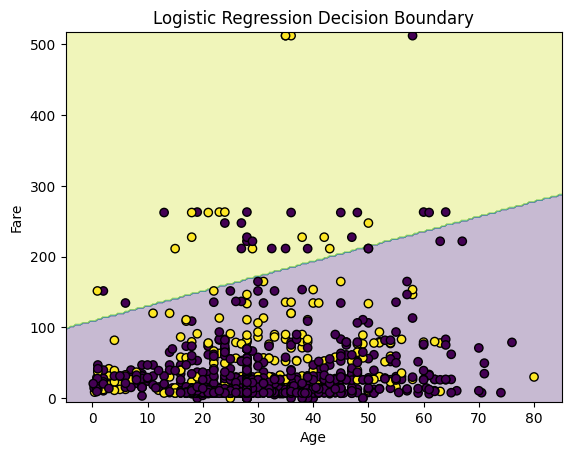

In [25]:
# Plot decision boundary
import matplotlib.pyplot as plt

x_min, x_max = X['Age'].min() - 5, X['Age'].max() + 5
y_min, y_max = X['Fare'].min() - 5, X['Fare'].max() + 5

xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

Z = log_reg.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X['Age'], X['Fare'], c=y, edgecolors='k', marker='o')
plt.xlabel("Age")
plt.ylabel("Fare")
plt.title("Logistic Regression Decision Boundary")
plt.show()

In [26]:
model = LogisticRegression(max_iter=1000, class_weight="balanced")
model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [27]:
y_predd = model.predict(X_test)

In [28]:
print("Accuracy:", accuracy_score(y_test, y_predd))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_predd))
print("\nClassification Report:\n", classification_report(y_test, y_predd, zero_division=0))

Accuracy: 0.7028265851795263

Confusion Matrix:
 [[768 199]
 [190 152]]

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.79      0.80       967
           1       0.43      0.44      0.44       342

    accuracy                           0.70      1309
   macro avg       0.62      0.62      0.62      1309
weighted avg       0.71      0.70      0.70      1309



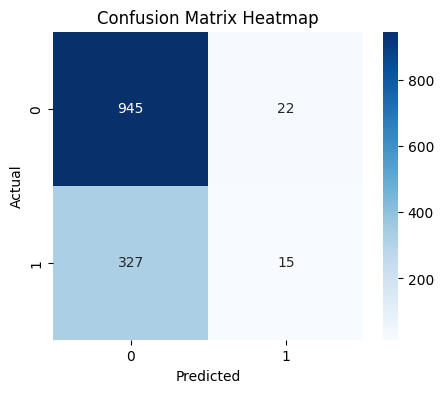

In [30]:
import seaborn as sns
cm = confusion_matrix(y_test, y_pred)
labels = [0, 1]

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix Heatmap")
plt.show()